In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
# Load data
df = pd.read_csv("house_prices.csv")


In [6]:
# Features & target
X = df.drop(columns=["Price", "Property_ID"])
y = df["Price"]

In [7]:
# Categorical encoding
cat = ["Location", "Property_Type"]
preprocessor = ColumnTransformer(
    [("cat", OneHotEncoder(handle_unknown="ignore"), cat)],
    remainder="passthrough"
)

X = preprocessor.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
# Model
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [9]:
# Prediction
pred = model.predict(X_test)


In [10]:
# Evaluation
mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
r2 = r2_score(y_test, pred)

print("HOUSE PRICE PREDICTION MODEL")
print("MAE:", mae)
print("MSE:", mse)
print("R² Score:", r2)

HOUSE PRICE PREDICTION MODEL
MAE: 2188736.343703824
MSE: 8454330868276.873
R² Score: 0.9406371185112222


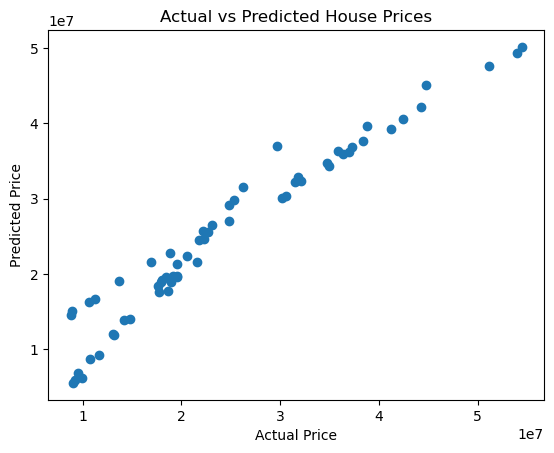

In [11]:
# Actual vs Predicted
plt.scatter(y_test, pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()